# COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset

### Imports

In [41]:
import random
from typing import Tuple, Dict
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

### Set Seed

In [42]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

### Data Loading

In [43]:
def get_xray_loaders(
    dataDir: str,
    seed: int,
    batch_size: int = 32,
) -> Tuple[DataLoader, DataLoader]:
    set_seed(seed)
 
    transform = T.Compose([
        T.Resize((64, 64)),
        T.ToTensor()
    ])
 
    fullDataset = torchvision.datasets.ImageFolder(root=dataDir, transform=transform)
 
    trainIndices = []
    testIndices  = []
 
    for classIdx in range(len(fullDataset.classes)):
 
        classIndices = []
        for i in range(len(fullDataset.samples)):
            _, label = fullDataset.samples[i]
            if label == classIdx:
                classIndices.append(i)
 
        random.shuffle(classIndices)
 
        splitIdx = int(len(classIndices) * 0.7)
 
        trainIndices += classIndices[:splitIdx]
        testIndices  += classIndices[splitIdx:]
 
    trainDataset = Subset(fullDataset, trainIndices)
    testDataset  = Subset(fullDataset, testIndices)
 
    train_loader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(testDataset,  batch_size=batch_size, shuffle=False)
 
    print(f"Train: {len(trainDataset)} | Test: {len(testDataset)}")
    return train_loader, test_loader

In [44]:
train_loader, test_loader = get_xray_loaders(dataDir="data/", seed=0)

Train: 3659 | Test: 1569


## MLP Model

In [45]:
#2 hidden layers
class MLP1(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layer1 = nn.Linear(12288, 512)
        self.bn1    = nn.BatchNorm1d(512)

        self.layer2 = nn.Linear(512, 256)
        self.bn2    = nn.BatchNorm1d(256)

        self.layer3 = nn.Linear(256, 3)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.flatten(x)

        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer3(x)
        return x

#3 hidden layers
class MLP2(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.layer1 = nn.Linear(12288, 512)
        self.bn1    = nn.BatchNorm1d(512)

        self.layer2 = nn.Linear(512, 256)
        self.bn2    = nn.BatchNorm1d(256)

        self.layer3 = nn.Linear(256, 128)
        self.bn3    = nn.BatchNorm1d(128)

        self.layer4 = nn.Linear(128, 3)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.flatten(x)

        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer4(x)
        return x

### Training

In [46]:
def train_one_epoch_MLP(model, loader, optimizer, device) -> Dict[str, float]:
    model.train()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss = lossFunction(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#train MLP1
set_seed(0)
mlp1Model     = MLP1(dropout_p=0.3).to(device)
mlp1Optimizer = torch.optim.Adam(mlp1Model.parameters(), lr=1e-3)

mlp1LossHistory = []
mlp1AccHistory  = []

epochs = 20
print("Training MLP1")
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_MLP(mlp1Model, train_loader, mlp1Optimizer, device)
    mlp1LossHistory.append(trainMetrics['loss'])
    mlp1AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")

Using device: cpu
Training MLP1
Epoch 1/20 | Loss: 0.5331 | Acc: 0.8713
Epoch 2/20 | Loss: 0.4629 | Acc: 0.9169
Epoch 3/20 | Loss: 0.4449 | Acc: 0.9262
Epoch 4/20 | Loss: 0.4219 | Acc: 0.9393
Epoch 5/20 | Loss: 0.4101 | Acc: 0.9470
Epoch 6/20 | Loss: 0.3992 | Acc: 0.9541
Epoch 7/20 | Loss: 0.3902 | Acc: 0.9579
Epoch 8/20 | Loss: 0.3870 | Acc: 0.9590
Epoch 9/20 | Loss: 0.3862 | Acc: 0.9612
Epoch 10/20 | Loss: 0.3751 | Acc: 0.9667
Epoch 11/20 | Loss: 0.3668 | Acc: 0.9732
Epoch 12/20 | Loss: 0.3622 | Acc: 0.9762
Epoch 13/20 | Loss: 0.3619 | Acc: 0.9740
Epoch 14/20 | Loss: 0.3653 | Acc: 0.9699
Epoch 15/20 | Loss: 0.3654 | Acc: 0.9710
Epoch 16/20 | Loss: 0.3506 | Acc: 0.9825
Epoch 17/20 | Loss: 0.3519 | Acc: 0.9798
Epoch 18/20 | Loss: 0.3474 | Acc: 0.9803
Epoch 19/20 | Loss: 0.3552 | Acc: 0.9792
Epoch 20/20 | Loss: 0.3472 | Acc: 0.9814


In [48]:
#train MLP2
set_seed(0)
mlp2Model     = MLP2(dropout_p=0.3).to(device)
mlp2Optimizer = torch.optim.Adam(mlp2Model.parameters(), lr=1e-3)

mlp2LossHistory = []
mlp2AccHistory  = []

print("Training MLP2")
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_MLP(mlp2Model, train_loader, mlp2Optimizer, device)
    mlp2LossHistory.append(trainMetrics['loss'])
    mlp2AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")

Training MLP2
Epoch 1/20 | Loss: 0.5553 | Acc: 0.8639
Epoch 2/20 | Loss: 0.4734 | Acc: 0.9076
Epoch 3/20 | Loss: 0.4369 | Acc: 0.9276
Epoch 4/20 | Loss: 0.4312 | Acc: 0.9317
Epoch 5/20 | Loss: 0.4071 | Acc: 0.9500
Epoch 6/20 | Loss: 0.4096 | Acc: 0.9445
Epoch 7/20 | Loss: 0.3952 | Acc: 0.9514
Epoch 8/20 | Loss: 0.3965 | Acc: 0.9505
Epoch 9/20 | Loss: 0.3968 | Acc: 0.9478
Epoch 10/20 | Loss: 0.3893 | Acc: 0.9549
Epoch 11/20 | Loss: 0.3823 | Acc: 0.9565
Epoch 12/20 | Loss: 0.3760 | Acc: 0.9637
Epoch 13/20 | Loss: 0.3697 | Acc: 0.9653
Epoch 14/20 | Loss: 0.3650 | Acc: 0.9667
Epoch 15/20 | Loss: 0.3618 | Acc: 0.9680
Epoch 16/20 | Loss: 0.3594 | Acc: 0.9710
Epoch 17/20 | Loss: 0.3581 | Acc: 0.9746
Epoch 18/20 | Loss: 0.3528 | Acc: 0.9740
Epoch 19/20 | Loss: 0.3509 | Acc: 0.9781
Epoch 20/20 | Loss: 0.3497 | Acc: 0.9776


### Comparison of MLP training vs. testing accuracy

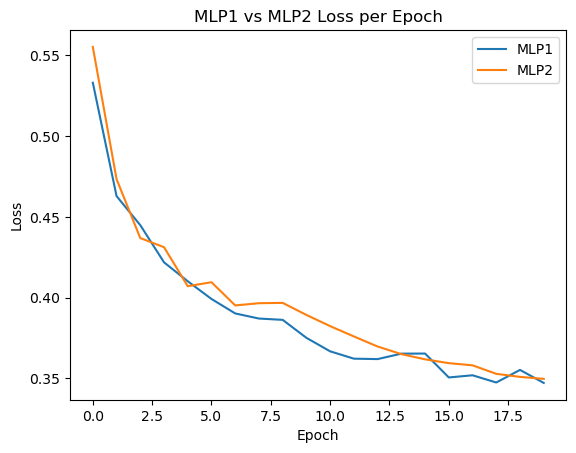

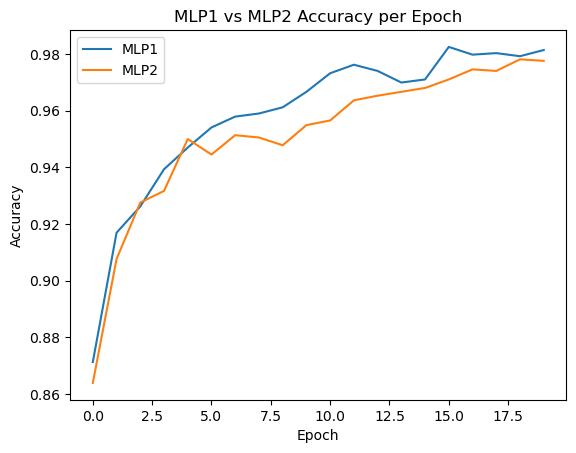

In [49]:
plt.plot(mlp1LossHistory, label="MLP1")
plt.plot(mlp2LossHistory, label="MLP2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP1 vs MLP2 Loss per Epoch")
plt.legend()
plt.show()

plt.plot(mlp1AccHistory, label="MLP1")
plt.plot(mlp2AccHistory, label="MLP2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP1 vs MLP2 Accuracy per Epoch")
plt.legend()
plt.show()

### Evaluation

In [50]:
@torch.no_grad()
def evaluate_MLP(model, loader, device) -> Dict[str, float]:
    model.eval()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss= lossFunction(outputs, labels)
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [51]:
mlp1TestMetrics = evaluate_MLP(mlp1Model, test_loader, device)
print(f"MLP1 Test Loss: {mlp1TestMetrics['loss']:.4f} | MLP1 Test Acc: {mlp1TestMetrics['acc']:.4f}")

mlp2TestMetrics = evaluate_MLP(mlp2Model, test_loader, device)
print(f"MLP2 Test Loss: {mlp2TestMetrics['loss']:.4f} | MLP2 Test Acc: {mlp2TestMetrics['acc']:.4f}")

MLP1 Test Loss: 0.4866 | MLP1 Test Acc: 0.8961
MLP2 Test Loss: 0.3811 | MLP2 Test Acc: 0.9516


### Confusion Matrix for MLP

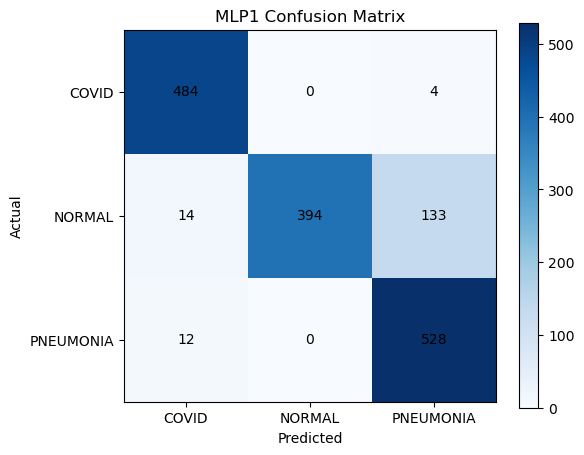

              precision    recall  f1-score   support

       COVID       0.95      0.99      0.97       488
      NORMAL       1.00      0.73      0.84       541
   PNEUMONIA       0.79      0.98      0.88       540

    accuracy                           0.90      1569
   macro avg       0.91      0.90      0.90      1569
weighted avg       0.91      0.90      0.89      1569



In [52]:
allPreds  = []
allLabels = []

mlp1Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp1Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("MLP1 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()
print(classification_report(allLabels, allPreds, target_names=classNames))

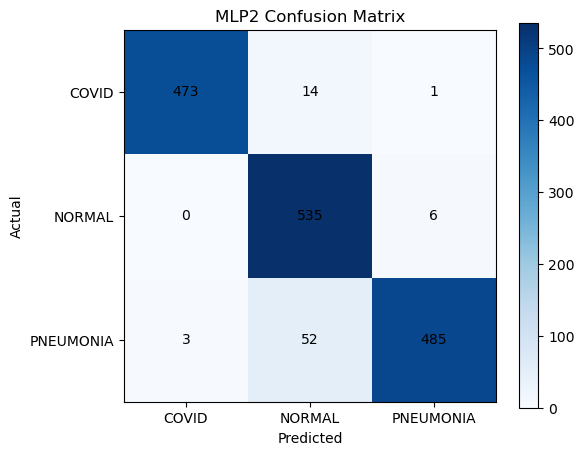

              precision    recall  f1-score   support

       COVID       0.99      0.97      0.98       488
      NORMAL       0.89      0.99      0.94       541
   PNEUMONIA       0.99      0.90      0.94       540

    accuracy                           0.95      1569
   macro avg       0.96      0.95      0.95      1569
weighted avg       0.96      0.95      0.95      1569



In [53]:
allPreds  = []
allLabels = []

mlp2Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp2Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("MLP2 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()
print(classification_report(allLabels, allPreds, target_names=classNames))

## CNN Model

In [54]:
class CNN1(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(16384, 256)
        self.fc2     = nn.Linear(256, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


class CNN2(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(8192, 256)
        self.fc2     = nn.Linear(256, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

### Training

In [55]:
def train_one_epoch_CNN(model, loader, optimizer, device) -> Dict[str, float]:
    model.train()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss    = lossFunction(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [56]:
#train CNN1
set_seed(0)
cnn1Model = CNN1(dropout_p=0.3).to(device)
cnn1Optimizer = torch.optim.Adam(cnn1Model.parameters(), lr=1e-3)

cnn1LossHistory = []
cnn1AccHistory  = []

epochs = 20
print("Training CNN1")
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_CNN(cnn1Model, train_loader, cnn1Optimizer, device)
    cnn1LossHistory.append(trainMetrics['loss'])
    cnn1AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")

Training CNN1
Epoch 1/20 | Loss: 0.6404 | Acc: 0.7967
Epoch 2/20 | Loss: 0.4430 | Acc: 0.9289
Epoch 3/20 | Loss: 0.4164 | Acc: 0.9399
Epoch 4/20 | Loss: 0.3905 | Acc: 0.9593
Epoch 5/20 | Loss: 0.3781 | Acc: 0.9639
Epoch 6/20 | Loss: 0.3729 | Acc: 0.9664
Epoch 7/20 | Loss: 0.3548 | Acc: 0.9792
Epoch 8/20 | Loss: 0.3465 | Acc: 0.9825
Epoch 9/20 | Loss: 0.3451 | Acc: 0.9833
Epoch 10/20 | Loss: 0.3310 | Acc: 0.9910
Epoch 11/20 | Loss: 0.3268 | Acc: 0.9918
Epoch 12/20 | Loss: 0.3246 | Acc: 0.9921
Epoch 13/20 | Loss: 0.3227 | Acc: 0.9937
Epoch 14/20 | Loss: 0.3170 | Acc: 0.9962
Epoch 15/20 | Loss: 0.3153 | Acc: 0.9962
Epoch 16/20 | Loss: 0.3103 | Acc: 0.9973
Epoch 17/20 | Loss: 0.3103 | Acc: 0.9989
Epoch 18/20 | Loss: 0.3062 | Acc: 0.9992
Epoch 19/20 | Loss: 0.3056 | Acc: 0.9992
Epoch 20/20 | Loss: 0.3056 | Acc: 0.9995


In [57]:
#train CNN2
set_seed(0)
cnn2Model     = CNN2(dropout_p=0.3).to(device)
cnn2Optimizer = torch.optim.Adam(cnn2Model.parameters(), lr=1e-3)

cnn2LossHistory = []
cnn2AccHistory  = []

print("\nTraining CNN2")
for epoch in range(1, epochs + 1):
    trainMetrics = train_one_epoch_CNN(cnn2Model, train_loader, cnn2Optimizer, device)
    cnn2LossHistory.append(trainMetrics['loss'])
    cnn2AccHistory.append(trainMetrics['acc'])
    print(f"Epoch {epoch}/{epochs} | Loss: {trainMetrics['loss']:.4f} | Acc: {trainMetrics['acc']:.4f}")


Training CNN2
Epoch 1/20 | Loss: 0.6142 | Acc: 0.8062
Epoch 2/20 | Loss: 0.4490 | Acc: 0.9202
Epoch 3/20 | Loss: 0.4164 | Acc: 0.9448
Epoch 4/20 | Loss: 0.3964 | Acc: 0.9524
Epoch 5/20 | Loss: 0.3772 | Acc: 0.9645
Epoch 6/20 | Loss: 0.3698 | Acc: 0.9656
Epoch 7/20 | Loss: 0.3586 | Acc: 0.9735
Epoch 8/20 | Loss: 0.3518 | Acc: 0.9779
Epoch 9/20 | Loss: 0.3483 | Acc: 0.9817
Epoch 10/20 | Loss: 0.3387 | Acc: 0.9841
Epoch 11/20 | Loss: 0.3348 | Acc: 0.9874
Epoch 12/20 | Loss: 0.3309 | Acc: 0.9899
Epoch 13/20 | Loss: 0.3247 | Acc: 0.9921
Epoch 14/20 | Loss: 0.3238 | Acc: 0.9929
Epoch 15/20 | Loss: 0.3201 | Acc: 0.9956
Epoch 16/20 | Loss: 0.3159 | Acc: 0.9956
Epoch 17/20 | Loss: 0.3125 | Acc: 0.9978
Epoch 18/20 | Loss: 0.3122 | Acc: 0.9964
Epoch 19/20 | Loss: 0.3085 | Acc: 0.9986
Epoch 20/20 | Loss: 0.3073 | Acc: 0.9986


### Comparison of CNN training vs. testing accuracy

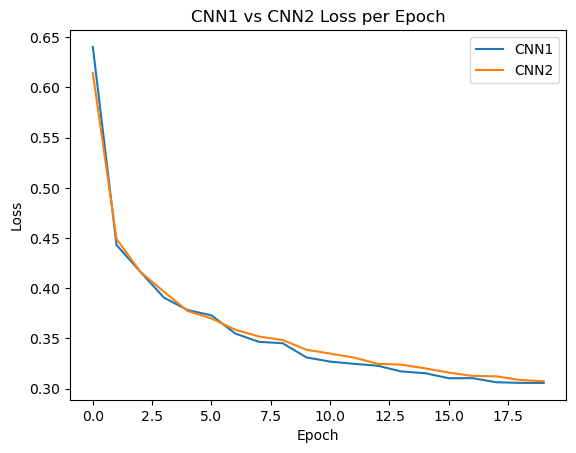

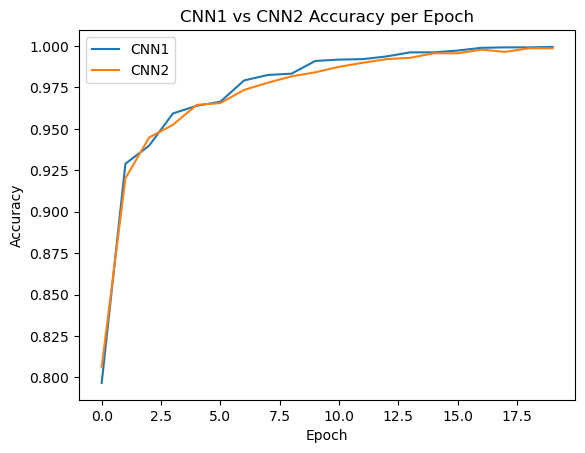

In [58]:
plt.plot(cnn1LossHistory, label="CNN1")
plt.plot(cnn2LossHistory, label="CNN2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN1 vs CNN2 Loss per Epoch")
plt.legend()
plt.show()

plt.plot(cnn1AccHistory, label="CNN1")
plt.plot(cnn2AccHistory, label="CNN2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN1 vs CNN2 Accuracy per Epoch")
plt.legend()
plt.show()

### Evaluation

In [59]:
@torch.no_grad()
def evaluate_CNN(model, loader, device) -> Dict[str, float]:
    model.eval()
    lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
    totalLoss = 0
    correct   = 0
    samples   = 0
 
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
 
        outputs = model(images)
        loss    = lossFunction(outputs, labels)
 
        totalLoss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        samples += images.size(0)
 
    return {"loss": totalLoss / samples, "acc": correct / samples}

In [60]:
cnn1TestMetrics = evaluate_CNN(cnn1Model, test_loader, device)
print(f"CNN1 Test Loss: {cnn1TestMetrics['loss']:.4f} | CNN1 Test Acc: {cnn1TestMetrics['acc']:.4f}")
cnn2TestMetrics = evaluate_CNN(cnn2Model, test_loader, device)
print(f"CNN2 Test Loss: {cnn2TestMetrics['loss']:.4f} | CNN2 Test Acc: {cnn2TestMetrics['acc']:.4f}")

CNN1 Test Loss: 0.3467 | CNN1 Test Acc: 0.9726
CNN2 Test Loss: 0.3450 | CNN2 Test Acc: 0.9771


### Confusion Matric for CNN

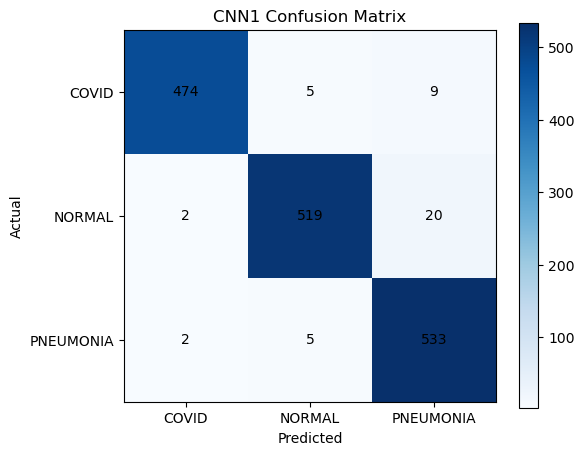

              precision    recall  f1-score   support

       COVID       0.99      0.97      0.98       488
      NORMAL       0.98      0.96      0.97       541
   PNEUMONIA       0.95      0.99      0.97       540

    accuracy                           0.97      1569
   macro avg       0.97      0.97      0.97      1569
weighted avg       0.97      0.97      0.97      1569



In [61]:
allPreds  = []
allLabels = []

cnn1Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn1Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("CNN1 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))

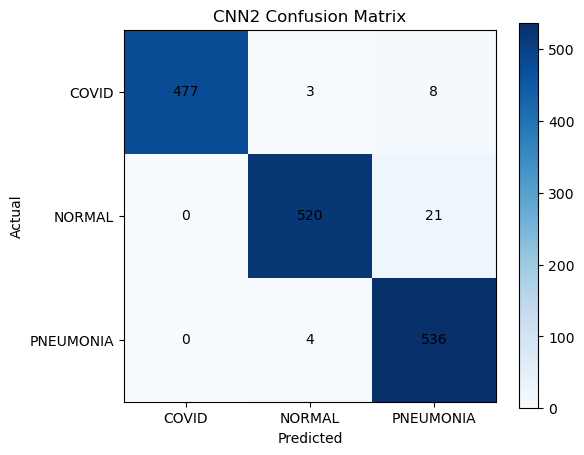

              precision    recall  f1-score   support

       COVID       1.00      0.98      0.99       488
      NORMAL       0.99      0.96      0.97       541
   PNEUMONIA       0.95      0.99      0.97       540

    accuracy                           0.98      1569
   macro avg       0.98      0.98      0.98      1569
weighted avg       0.98      0.98      0.98      1569



In [62]:
allPreds  = []
allLabels = []

cnn2Model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn2Model(images)
        predictions = outputs.argmax(dim=1)
        allPreds  += predictions.cpu().tolist()
        allLabels += labels.tolist()

classNames = ["COVID", "NORMAL", "PNEUMONIA"]

cm = confusion_matrix(allLabels, allPreds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("CNN2 Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], classNames)
plt.yticks([0, 1, 2], classNames)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))